# Football Match Prediction 


## Section 0: Database Explorer


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
DB_PATH = r"C:\Users\bhara\Downloads\Desktop\Sem Notes\sem--8\Open Lab-III\database.sqlite"
conn = sqlite3.connect(DB_PATH)
# 1. LIST ALL TABLES
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn
)
print("DATABASE TABLE OVERVIEW")
for t in tables["name"]:
    count = pd.read_sql(f"SELECT COUNT(*) as n FROM {t};", conn)["n"][0]
    cols  = pd.read_sql(f"PRAGMA table_info({t});", conn)
    print(f"{t:<25} {count:>6,} rows  {len(cols):>3} cols")

DATABASE TABLE OVERVIEW
Country                       11 rows    2 cols
League                        11 rows    3 cols
Match                     25,979 rows  115 cols
Player                    11,060 rows    7 cols
Player_Attributes         183,978 rows   42 cols
Team                         299 rows    5 cols
Team_Attributes            1,458 rows   25 cols
sqlite_sequence                7 rows    2 cols


In [2]:
# 2. SCHEMA: columns + types for each table
print("\n\n TABLE SCHEMAS")
print("=" * 65)
for t in tables["name"]:
    info = pd.read_sql(f"PRAGMA table_info({t});", conn)
    print(f"\n  {t}")
    print(f"  {'Column':<35} {'Type':<15} {'NotNull'}")
    print(f"  {'─'*35} {'─'*15} {'─'*7}")
    for _, row in info.iterrows():
        nn = "✓" if row["notnull"] else ""
        pk = " " if row["pk"] else ""
        print(f"  {row['name']:<35} {row['type']:<15} {nn}{pk}")



 TABLE SCHEMAS

  Country
  Column                              Type            NotNull
  ─────────────────────────────────── ─────────────── ───────
  id                                  INTEGER          
  name                                TEXT            

  League
  Column                              Type            NotNull
  ─────────────────────────────────── ─────────────── ───────
  id                                  INTEGER          
  country_id                          INTEGER         
  name                                TEXT            

  Match
  Column                              Type            NotNull
  ─────────────────────────────────── ─────────────── ───────
  id                                  INTEGER          
  country_id                          INTEGER         
  league_id                           INTEGER         
  season                              TEXT            
  stage                               INTEGER         
  date                      

In [3]:
# 3. SAMPLE ROWS for each table
print("\n\n SAMPLE DATA PER TABLE")
for t in tables["name"]:
    print(f"\n─── {t} (first 3 rows) ───")
    sample = pd.read_sql(f"SELECT * FROM {t} LIMIT 3;", conn)
    display(sample)



 SAMPLE DATA PER TABLE

─── Country (first 3 rows) ───


,id,name
0,1,Belgium
1,1729,England
2,4769,France



─── League (first 3 rows) ───


,id,country_id,name
0,1,1,Belgium Jupiler League
1,1729,1729,England Premier League
2,4769,4769,France Ligue 1



─── Match (first 3 rows) ───


...

,id,team_api_id,team_fifa_api_id,team_long_name,team_short_name
0,1,9987,673,KRC Genk,GEN
1,2,9993,675,Beerschot AC,BAC
2,3,10000,15005,SV Zulte-Waregem,ZUL



─── Team_Attributes (first 3 rows) ───


,id,team_fifa_api_id,team_api_id,date,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,...,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,1,434,9930,2010-02-22 00:00:00,60,Balanced,NaN,Little,50,Mixed,...,55,Normal,Organised,50,Medium,55,Press,45,Normal,Cover
1,2,434,9930,2014-09-19 00:00:00,52,Balanced,48.0,Normal,56,Mixed,...,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
2,3,434,9930,2015-09-10 00:00:00,47,Balanced,41.0,Normal,54,Mixed,...,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover



─── sqlite_sequence (first 3 rows) ───


,name,seq
0,Team,103916
1,Country,51958
2,League,51958


In [4]:
# 4. NULL ANALYSIS for main tables
print("\n\n🔍 NULL VALUE ANALYSIS")
print("=" * 55)
for t in ["Match", "Player_Attributes", "Team_Attributes"]:
    df_t    = pd.read_sql(f"SELECT * FROM {t} LIMIT 5000;", conn)
    null_pct = (df_t.isnull().mean() * 100).sort_values(ascending=False)
    high     = null_pct[null_pct > 10]
    print(f"\n  {t}: {len(df_t.columns)} columns  |  "
          f"{len(high)} columns with >10% nulls")
    if len(high):
        for col, pct in high.items():
            print(f"    {col:<40} {pct:>5.1f}%")
    else:
        print("  No significant nulls")



🔍 NULL VALUE ANALYSIS

  Match: 115 columns  |  20 columns with >10% nulls
    PSD                                       55.4%
    PSA                                       55.4%
    PSH                                       55.4%
    goal                                      39.2%
    shoton                                    39.2%
    cross                                     39.2%
    foulcommit                                39.2%
    card                                      39.2%
    possession                                39.2%
    shotoff                                   39.2%
    corner                                    39.2%
    BSD                                       33.0%
    BSA                                       33.0%
    BSH                                       33.0%
    GBA                                       33.0%
    GBH                                       33.0%
    GBD                                       33.0%
    SJA                                

In [5]:
# 5. KEY STATISTICS per table
match_df_raw  = pd.read_sql("SELECT * FROM Match;",             conn)
player_df     = pd.read_sql("SELECT * FROM Player;",            conn)
player_att    = pd.read_sql("SELECT * FROM Player_Attributes;", conn)
team_df       = pd.read_sql("SELECT * FROM Team;",              conn)
team_att      = pd.read_sql("SELECT * FROM Team_Attributes;",   conn)
league_df     = pd.read_sql("SELECT * FROM League;",            conn)
country_df    = pd.read_sql("SELECT * FROM Country;",           conn)
conn.close()
match_df_raw["date"] = pd.to_datetime(match_df_raw["date"])
print("\n\n KEY DATABASE STATISTICS")
print("═" * 55)
print(f"  Matches         : {len(match_df_raw):,}")
print(f"  Seasons covered : {sorted(match_df_raw['season'].unique())}")
print(f"  Date range      : {match_df_raw['date'].min().date()} → {match_df_raw['date'].max().date()}")
print(f"  Leagues         : {len(match_df_raw['league_id'].unique())}")
print(f"  Home teams      : {match_df_raw['home_team_api_id'].nunique()}")
print(f"  Players         : {len(player_df):,}")
print(f"  Player ratings  : {len(player_att):,}")
print(f"  Teams           : {len(team_df):,}")
print(f"  Team attr rows  : {len(team_att):,}")
print(f"  Countries       : {len(country_df):,}")
print(f"  Leagues table   : {len(league_df):,}")



 KEY DATABASE STATISTICS
═══════════════════════════════════════════════════════
  Matches         : 25,979
  Seasons covered : ['2008/2009', '2009/2010', '2010/2011', '2011/2012', '2012/2013', '2013/2014', '2014/2015', '2015/2016']
  Date range      : 2008-07-18 → 2016-05-25
  Leagues         : 11
  Home teams      : 299
  Players         : 11,060
  Player ratings  : 183,978
  Teams           : 299
  Team attr rows  : 1,458
  Countries       : 11
  Leagues table   : 11


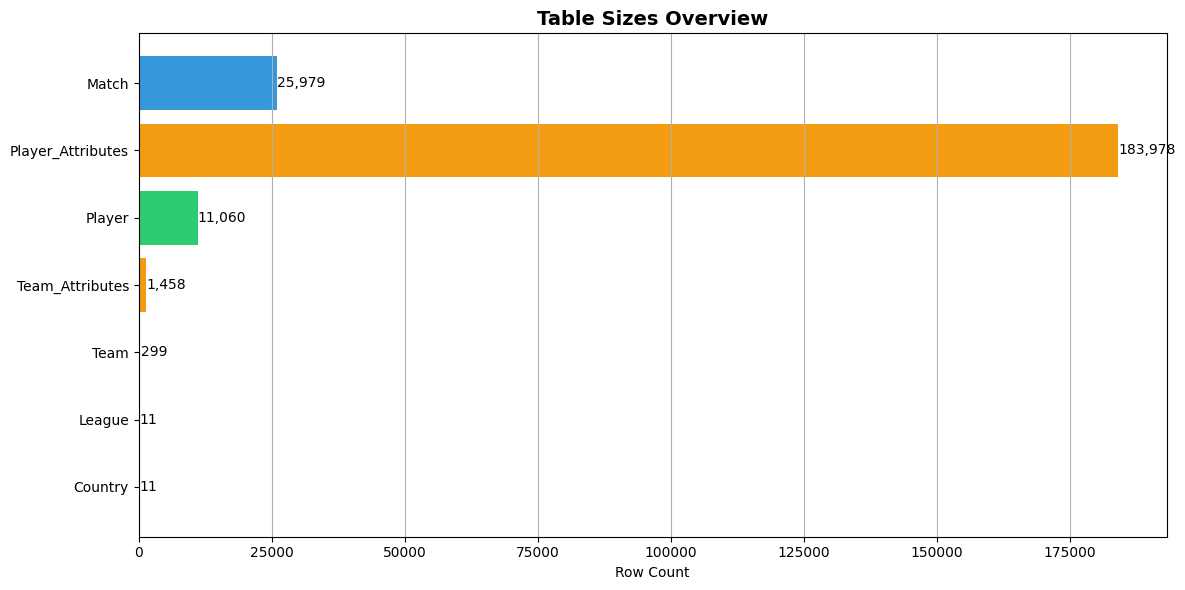

In [6]:
# 6. VISUALIZE DATABASE STRUCTURE (LIGHT THEME)


fig = plt.figure(figsize=(12,6))
gs = gridspec.GridSpec(1, 1, figure=fig)

# ── Table sizes bar chart ──
ax1 = fig.add_subplot(gs[0])

tbl_names  = ["Match", "Player_Attributes", "Player", "Team_Attributes", "Team", "League", "Country"]
tbl_counts = [len(match_df_raw), len(player_att), len(player_df),
              len(team_att), len(team_df), len(league_df), len(country_df)]

bars = ax1.barh(tbl_names[::-1], tbl_counts[::-1],
                color=["#3498db","#f39c12","#2ecc71","#f39c12","#2ecc71","#e74c3c","#e74c3c"][::-1])

for bar, val in zip(bars, tbl_counts[::-1]):
    ax1.text(val + 50, bar.get_y() + bar.get_height()/2,
             f"{val:,}", va="center", fontsize=10)

ax1.set_xlabel("Row Count")
ax1.set_title("Table Sizes Overview", fontsize=14, fontweight="bold")
ax1.grid(axis="x")

plt.tight_layout()
plt.show()

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define colors (fix for NameError)
ACCENT = "#3498db"
GREEN  = "#2ecc71"
GOLD   = "#f39c12"
RED    = "#e74c3c"

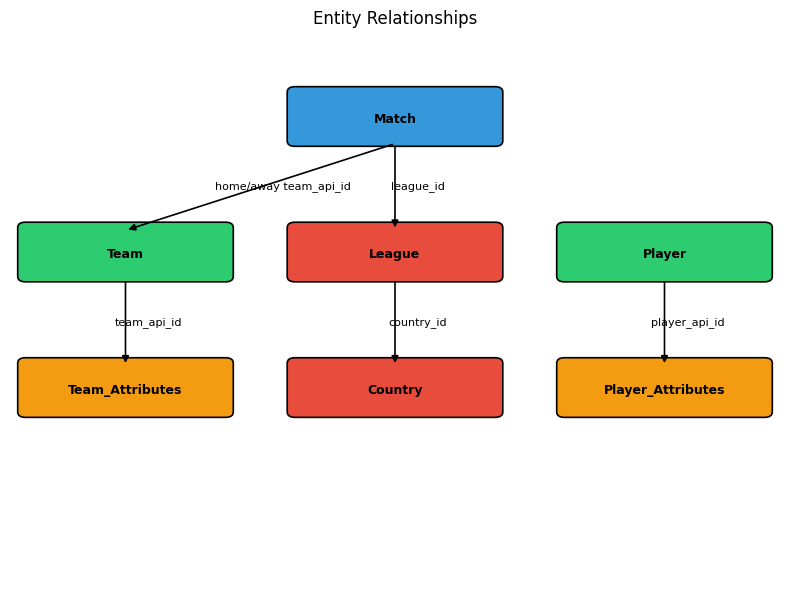

In [9]:
fig, ax2 = plt.subplots(figsize=(8,6), facecolor="white")
ax2.set_facecolor("white")

ax2.set_xlim(0,10)
ax2.set_ylim(0,10)
ax2.axis("off")

ax2.set_title("Entity Relationships", fontsize=12, pad=10, color="black")

boxes = {
    "Match":             (5.0, 8.5, ACCENT),
    "Team":              (1.5, 6.0, GREEN),
    "Team_Attributes":   (1.5, 3.5, GOLD),
    "Player":            (8.5, 6.0, GREEN),
    "Player_Attributes": (8.5, 3.5, GOLD),
    "League":            (5.0, 6.0, RED),
    "Country":           (5.0, 3.5, RED),
}

for name, (x, y, color) in boxes.items():
    ax2.add_patch(mpatches.FancyBboxPatch(
        (x-1.3, y-0.4), 2.6, 0.9,
        boxstyle="round,pad=0.1",
        facecolor=color,
        edgecolor="black",
        linewidth=1.2
    ))

    ax2.text(x, y, name,
             ha="center",
             va="center",
             fontsize=9,
             color="black",
             fontweight="bold")

links = [
    ("Match", "Team", "home/away team_api_id"),
    ("Match", "League", "league_id"),
    ("League", "Country", "country_id"),
    ("Team", "Team_Attributes", "team_api_id"),
    ("Player", "Player_Attributes", "player_api_id"),
]

for src, dst, lbl in links:
    sx, sy, _ = boxes[src]
    dx, dy, _ = boxes[dst]

    ax2.annotate("",
        xy=(dx, dy+0.45),
        xytext=(sx, sy-0.45),
        arrowprops=dict(arrowstyle="-|>", color="black", lw=1.2)
    )

    mx, my = (sx+dx)/2, (sy+dy)/2
    ax2.text(mx+0.3, my, lbl,
             fontsize=8,
             color="black",
             ha="center",
             va="center")

plt.tight_layout()
plt.show()

C:\Users\bhara\AppData\Local\Temp\ipykernel_3048\3994965906.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


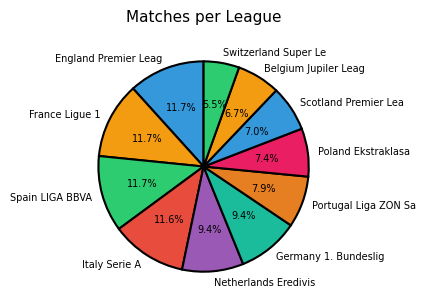

In [10]:
fig = plt.figure(figsize=(18, 14), facecolor="white")

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# ── Matches per League ────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor("white")

league_counts = match_df_raw.merge(
    league_df[["id","name"]], left_on="league_id", right_on="id", how="left"
)["name"].value_counts()

wedge_colors = [ACCENT, GOLD, GREEN, RED, "#9b59b6", "#1abc9c", "#e67e22", "#e91e63"]

ax3.pie(
    league_counts.values,
    labels=[n[:20] for n in league_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    colors=wedge_colors[:len(league_counts)],
    wedgeprops={"edgecolor": "black", "linewidth": 1.5},
    textprops={"color": "black", "fontsize": 7}
)

ax3.set_title("Matches per League", fontsize=11, pad=10, color="black")

plt.tight_layout()
plt.show()

C:\Users\bhara\AppData\Local\Temp\ipykernel_3048\898539184.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


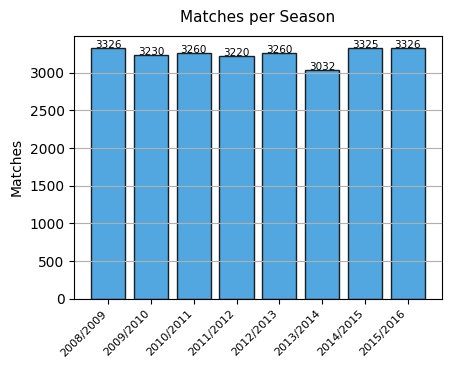

In [11]:
fig = plt.figure(figsize=(18, 14), facecolor="white")

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# ── Matches per Season ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor("white")

season_match = match_df_raw.groupby("season").size()

ax4.bar(
    range(len(season_match)),
    season_match.values,
    color=ACCENT,
    alpha=0.85,
    edgecolor="black"
)

ax4.set_xticks(range(len(season_match)))
ax4.set_xticklabels(season_match.index, rotation=45, ha="right", fontsize=8)

ax4.set_ylabel("Matches", color="black")
ax4.set_title("Matches per Season", fontsize=11, pad=10, color="black")

ax4.tick_params(colors="black")
ax4.grid(axis="y")

for i, v in enumerate(season_match.values):
    ax4.text(i, v+10, str(v), ha="center", fontsize=7.5, color="black")

plt.tight_layout()
plt.show()

C:\Users\bhara\AppData\Local\Temp\ipykernel_3048\684750196.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


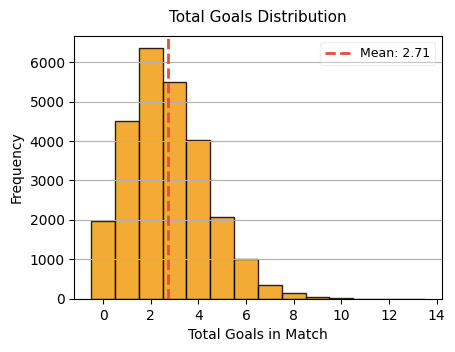

In [12]:
fig = plt.figure(figsize=(18, 14), facecolor="white")


gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# ── Goals distribution across all matches ─────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor("white")

total_goals = match_df_raw["home_team_goal"] + match_df_raw["away_team_goal"]

ax5.hist(
    total_goals,
    bins=range(0, 15),
    color=GOLD,
    edgecolor="black",
    alpha=0.85,
    align="left"
)

ax5.axvline(
    total_goals.mean(),
    color=RED,
    linestyle="--",
    linewidth=2,
    label=f"Mean: {total_goals.mean():.2f}"
)

ax5.set_xlabel("Total Goals in Match", color="black")
ax5.set_ylabel("Frequency", color="black")
ax5.set_title("Total Goals Distribution", fontsize=11, pad=10, color="black")

ax5.tick_params(colors="black")

ax5.legend(fontsize=9, framealpha=0.3)
ax5.grid(axis="y")

plt.tight_layout()
plt.show()

C:\Users\bhara\AppData\Local\Temp\ipykernel_3048\3879425675.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


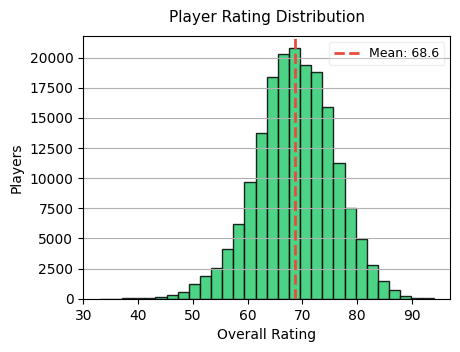

In [13]:
fig = plt.figure(figsize=(18, 14), facecolor="white")

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# ── Player overall rating distribution ────────────────
ax6 = fig.add_subplot(gs[2, 0])
ax6.set_facecolor("white")

if "overall_rating" in player_att.columns:
    ratings = player_att["overall_rating"].dropna()

    ax6.hist(
        ratings,
        bins=30,
        color=GREEN,
        edgecolor="black",
        alpha=0.85
    )

    ax6.axvline(
        ratings.mean(),
        color=RED,
        linestyle="--",
        linewidth=2,
        label=f"Mean: {ratings.mean():.1f}"
    )

    ax6.set_xlabel("Overall Rating", color="black")
    ax6.set_ylabel("Players", color="black")
    ax6.set_title("Player Rating Distribution", fontsize=11, pad=10, color="black")

    ax6.tick_params(colors="black")

    ax6.legend(fontsize=9, framealpha=0.3)
    ax6.grid(axis="y")

plt.tight_layout()
plt.show()

C:\Users\bhara\AppData\Local\Temp\ipykernel_3048\3102261403.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


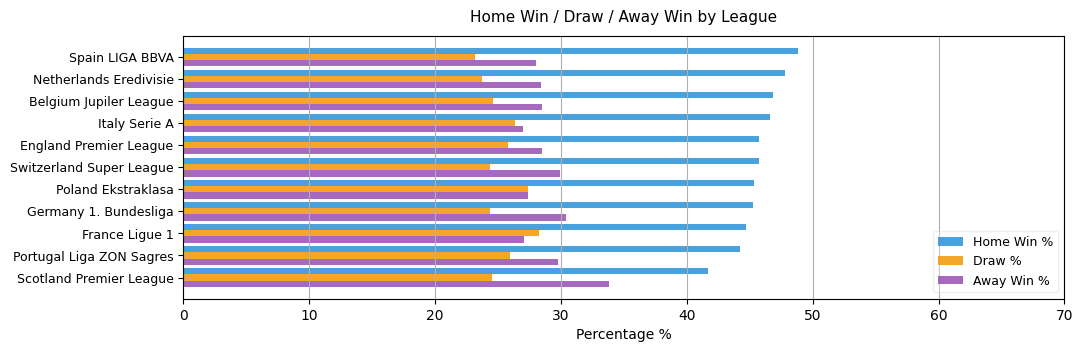

In [14]:
fig = plt.figure(figsize=(18, 14), facecolor="white")

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# ── Home vs Away win rate per league ──────────────────
ax7 = fig.add_subplot(gs[2, 1:])
ax7.set_facecolor("white")

league_result = match_df_raw.merge(
    league_df[["id","name"]], left_on="league_id", right_on="id", how="left"
)

league_result["home_win"] = league_result["home_team_goal"] > league_result["away_team_goal"]
league_result["draw"]     = league_result["home_team_goal"] == league_result["away_team_goal"]
league_result["away_win"] = league_result["home_team_goal"] < league_result["away_team_goal"]

lg_stats = league_result.groupby("name")[["home_win","draw","away_win"]].mean() * 100
lg_stats = lg_stats.sort_values("home_win", ascending=True)

x_lg = np.arange(len(lg_stats))
w_lg = 0.28

ax7.barh(x_lg + w_lg, lg_stats["home_win"], w_lg,
         label="Home Win %", color=ACCENT, alpha=0.9)

ax7.barh(x_lg, lg_stats["draw"], w_lg,
         label="Draw %", color=GOLD, alpha=0.9)

ax7.barh(x_lg - w_lg, lg_stats["away_win"], w_lg,
         label="Away Win %", color="#9b59b6", alpha=0.9)

ax7.set_yticks(x_lg)
ax7.set_yticklabels([n[:28] for n in lg_stats.index], fontsize=9, color="black")

ax7.set_xlabel("Percentage %", color="black")
ax7.set_title("Home Win / Draw / Away Win by League", fontsize=11, pad=10, color="black")

ax7.tick_params(colors="black")

ax7.legend(fontsize=9, framealpha=0.3, loc="lower right")
ax7.grid(axis="x")

ax7.set_xlim(0, 70)

plt.tight_layout()
plt.show()

## Section 1: Configuration

In [15]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, recall_score, mean_absolute_error
)

# ── Update DB_PATH to your local file ──
DB_PATH      = r"C:\Users\bhara\Downloads\Desktop\Sem Notes\sem--8\Open Lab-III\database.sqlite"
WINDOW_SHORT = 3
WINDOW_LONG  = 5
ELO_INITIAL  = 1500
ELO_K        = 20
ELO_HOME_ADV = 100
TARGET_MAP   = {"Loss": 0, "Draw": 1, "Win": 2}
LABEL_NAMES  = ["Loss", "Draw", "Win"]

FEATURE_COLS = [
    "home_gf_last3", "home_ga_last3", "home_gd_last3", "home_wins_last3", "home_pts_last3",
    "away_gf_last3", "away_ga_last3", "away_gd_last3", "away_wins_last3", "away_pts_last3",
    "home_gf_last5", "home_ga_last5", "home_gd_last5", "home_wins_last5",
    "away_gf_last5", "away_ga_last5", "away_gd_last5", "away_wins_last5",
    "diff_gd_last3", "diff_wins_last3", "diff_pts_last3",
    "diff_gd_last5", "diff_wins_last5",
    "home_cum_pts", "away_cum_pts",
    "elo_home", "elo_away", "elo_diff", "elo_home_win_prob",
    "h2h_home_winrate",
    # ── NEW: Betting market implied probabilities ──
    "odds_home_prob", "odds_draw_prob", "odds_away_prob",
]

print("Configuration loaded ")

Configuration loaded 


## Section 2: Data Loading

In [16]:
def load_data(db_path: str) -> pd.DataFrame:
    """Load Match table joined with Team names."""
    conn = sqlite3.connect(db_path)
    match_query = """
        SELECT m.match_api_id, m.season, m.date, m.league_id,
               m.home_team_api_id, m.away_team_api_id,
               m.home_team_goal, m.away_team_goal,
               m.B365H, m.B365D, m.B365A,
               m.BWH,  m.BWD,  m.BWA,
               m.IWH,  m.IWD,  m.IWA
        FROM Match m
    """
    df = pd.read_sql(match_query, conn)
    team_df = pd.read_sql("SELECT team_api_id, team_long_name FROM Team;", conn)
    conn.close()

    df = df.merge(team_df, left_on="home_team_api_id", right_on="team_api_id", how="left") \
           .rename(columns={"team_long_name": "home_team"}).drop(columns=["team_api_id"])
    df = df.merge(team_df, left_on="away_team_api_id", right_on="team_api_id", how="left") \
           .rename(columns={"team_long_name": "away_team"}).drop(columns=["team_api_id"])

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    def match_result(row):
        if row["home_team_goal"] > row["away_team_goal"]: return "Win"
        elif row["home_team_goal"] < row["away_team_goal"]: return "Loss"
        return "Draw"

    df["result"] = df.apply(match_result, axis=1)
    df["target"] = df["result"].map(TARGET_MAP)

    # ── Betting odds → implied probabilities (average across bookmakers) ──
    # Raw implied prob = 1/odds; divide by sum to remove bookmaker margin
    for h_col, d_col, a_col in [("B365H","B365D","B365A"),
                                  ("BWH","BWD","BWA"),
                                  ("IWH","IWD","IWA")]:
        if all(c in df.columns for c in [h_col, d_col, a_col]):
            df[h_col] = pd.to_numeric(df[h_col], errors="coerce")
            df[d_col] = pd.to_numeric(df[d_col], errors="coerce")
            df[a_col] = pd.to_numeric(df[a_col], errors="coerce")

    odds_cols = {
        "odds_home": ["B365H","BWH","IWH"],
        "odds_draw": ["B365D","BWD","IWD"],
        "odds_away": ["B365A","BWA","IWA"],
    }
    for name, cols in odds_cols.items():
        available = [c for c in cols if c in df.columns]
        if available:
            raw_prob = df[available].apply(lambda x: 1/x).mean(axis=1)
            df[name + "_raw"] = raw_prob

    if all(c in df.columns for c in ["odds_home_raw","odds_draw_raw","odds_away_raw"]):
        total = df["odds_home_raw"] + df["odds_draw_raw"] + df["odds_away_raw"]
        df["odds_home_prob"] = df["odds_home_raw"] / total
        df["odds_draw_prob"] = df["odds_draw_raw"] / total
        df["odds_away_prob"] = df["odds_away_raw"] / total
        df.drop(columns=["odds_home_raw","odds_draw_raw","odds_away_raw"], inplace=True)
        print(f"  → Betting odds loaded for {df['odds_home_prob'].notna().sum():,} matches")
    else:
        df["odds_home_prob"] = np.nan
        df["odds_draw_prob"] = np.nan
        df["odds_away_prob"] = np.nan
        print("  → Betting odds columns not found, filled with NaN")

    print(f"Loaded {len(df):,} matches | Seasons: {sorted(df['season'].unique())}")
    return df

df = load_data(DB_PATH)
df.head()

print(f"Shape: {df.shape}")
print(f"\nClass distribution:")
print(df['result'].value_counts())

  → Betting odds loaded for 22,596 matches
Loaded 25,979 matches | Seasons: ['2008/2009', '2009/2010', '2010/2011', '2011/2012', '2012/2013', '2013/2014', '2014/2015', '2015/2016']
Shape: (25979, 24)

Class distribution:
result
Win     11917
Loss     7466
Draw     6596
Name: count, dtype: int64


## Section 3: ELO Rating System

> Computed chronologically before any feature merge to prevent leakage.

In [17]:
def compute_elo(df: pd.DataFrame) -> pd.DataFrame:
    ratings = {}

    def _exp(ra, rb):
        return 1.0 / (1.0 + 10.0 ** ((rb - ra) / 400.0))

    elo_home_list, elo_away_list = [], []

    for _, row in df.iterrows():
        h, a = row["home_team"], row["away_team"]
        rh = ratings.get(h, ELO_INITIAL)
        ra = ratings.get(a, ELO_INITIAL)
        elo_home_list.append(rh)
        elo_away_list.append(ra)

        exp_h = _exp(rh + ELO_HOME_ADV, ra)
        exp_a = 1.0 - exp_h
        act_h = 1.0 if row["result"]=="Win" else (0.0 if row["result"]=="Loss" else 0.5)
        act_a = 1.0 - act_h

        ratings[h] = rh + ELO_K * (act_h - exp_h)
        ratings[a] = ra + ELO_K * (act_a - exp_a)

    df = df.copy()
    df["elo_home"] = elo_home_list
    df["elo_away"] = elo_away_list
    df["elo_diff"] = df["elo_home"] - df["elo_away"]
    df["elo_home_win_prob"] = 1.0 / (1.0 + 10.0 ** (-df["elo_diff"] / 400.0))
    return df

df = compute_elo(df)
df[["date","home_team","away_team","result","elo_home","elo_away","elo_diff","elo_home_win_prob"]].head(8)

,date,home_team,away_team,result,elo_home,elo_away,elo_diff,elo_home_win_prob
0,2008-07-18,BSC Young Boys,FC Basel,Loss,1500.0000,1500.0000,0.0000,0.500000
1,2008-07-19,FC Aarau,FC Sion,Win,1500.0000,1500.0000,0.0000,0.500000
2,2008-07-20,FC Luzern,FC Vaduz,Loss,1500.0000,1500.0000,0.0000,0.500000
3,2008-07-20,Neuchâtel Xamax,FC Zürich,Loss,1500.0000,1500.0000,0.0000,0.500000
4,2008-07-23,AC Bellinzona,Neuchâtel Xamax,Loss,1500.0000,1487.1987,12.8013,0.518414
5,2008-07-23,FC Basel,Grasshopper Club Zürich,Win,1512.8013,1500.0000,12.8013,0.518414
6,2008-07-23,FC Zürich,FC Luzern,Win,1512.8013,1487.1987,25.6026,0.536779
7,2008-07-24,FC Sion,BSC Young Boys,Win,1492.8013,1487.1987,5.6026,0.508062


## Section 4: Rolling Team Form Features

> `shift(1)` on every rolling window prevents look-ahead leakage.

In [18]:
def compute_team_form(df: pd.DataFrame) -> pd.DataFrame:
    home = df[["date","home_team","home_team_goal","away_team_goal"]].copy()
    home.columns = ["date","team","gf","ga"]; home["is_home"] = 1
    away = df[["date","away_team","away_team_goal","home_team_goal"]].copy()
    away.columns = ["date","team","gf","ga"]; away["is_home"] = 0

    tm = pd.concat([home, away], ignore_index=True)
    tm["win"]    = (tm["gf"] > tm["ga"]).astype(int)
    tm["draw"]   = (tm["gf"] == tm["ga"]).astype(int)
    tm["points"] = tm["win"] * 3 + tm["draw"]
    tm = tm.sort_values(["team","date"]).reset_index(drop=True)

    def _roll(series, w):
        return series.shift(1).rolling(w, min_periods=1).mean()

    for w, tag in [(WINDOW_SHORT, "3"), (WINDOW_LONG, "5")]:
        tm[f"gf_last{tag}"]   = tm.groupby("team")["gf"].transform(lambda x: _roll(x, w))
        tm[f"ga_last{tag}"]   = tm.groupby("team")["ga"].transform(lambda x: _roll(x, w))
        tm[f"wins_last{tag}"] = tm.groupby("team")["win"].transform(lambda x: _roll(x, w))
        tm[f"pts_last{tag}"]  = tm.groupby("team")["points"].transform(lambda x: _roll(x, w))
        tm[f"gd_last{tag}"]   = tm[f"gf_last{tag}"] - tm[f"ga_last{tag}"]

    tm["cum_pts"] = tm.groupby("team")["points"].transform(
        lambda x: x.shift(1).expanding().mean()
    )
    return tm

def _merge_form(df, form_df, side):
    team_col = f"{side}_team"
    drop_cols = {"is_home","win","draw","points","gf","ga"}
    cols = [c for c in form_df.columns if c not in drop_cols]
    merged = df.merge(form_df[cols], left_on=[team_col,"date"], right_on=["team","date"], how="left")
    merged = merged.drop(columns=["team"])
    merged = merged.rename(columns={c: f"{side}_{c}" for c in cols if c != "date"})
    return merged

form_df = compute_team_form(df)
df = _merge_form(df, form_df, "home")
df = _merge_form(df, form_df, "away")

# Differential features
df["diff_gd_last3"]   = df["home_gd_last3"]   - df["away_gd_last3"]
df["diff_wins_last3"] = df["home_wins_last3"]  - df["away_wins_last3"]
df["diff_pts_last3"]  = df["home_pts_last3"]   - df["away_pts_last3"]
df["diff_gd_last5"]   = df["home_gd_last5"]    - df["away_gd_last5"]
df["diff_wins_last5"] = df["home_wins_last5"]  - df["away_wins_last5"]

print("Form features merged ✓")
df[["home_team","away_team","home_gd_last3","away_gd_last3","diff_gd_last3"]].head()

Form features merged ✓


,home_team,away_team,home_gd_last3,away_gd_last3,diff_gd_last3
0,BSC Young Boys,FC Basel,NaN,NaN,NaN
1,FC Aarau,FC Sion,NaN,NaN,NaN
2,FC Luzern,FC Vaduz,NaN,NaN,NaN
3,Neuchâtel Xamax,FC Zürich,NaN,NaN,NaN
4,AC Bellinzona,Neuchâtel Xamax,NaN,-1.0,NaN


## Section 5: Head-to-Head Win Rate

In [19]:
def compute_h2h(df: pd.DataFrame) -> pd.DataFrame:
    """
    Fast O(n) H2H computation using groupby + cumsum.
    Creates a canonical pair key so (A vs B) and (B vs A) share the same group.
    shift(1) ensures only prior matches are used — no leakage.
    """
    df = df.copy().reset_index(drop=True)

    # Canonical pair key: always sort team names alphabetically
    df["_t1"] = df[["home_team","away_team"]].min(axis=1)
    df["_t2"] = df[["home_team","away_team"]].max(axis=1)
    df["_pair"] = df["_t1"] + "|||" + df["_t2"]

    # Did the alphabetically-first team win?
    df["_t1_win"] = (
        ((df["home_team"] == df["_t1"]) & (df["result"] == "Win")) |
        ((df["away_team"] == df["_t1"]) & (df["result"] == "Loss"))
    ).astype(int)

    df = df.sort_values("date").reset_index(drop=True)

    # Cumulative wins and games for each pair (shifted — excludes current row)
    df["_pair_cumwins"] = df.groupby("_pair")["_t1_win"].transform(
        lambda x: x.shift(1).cumsum()
    )
    df["_pair_cumgames"] = df.groupby("_pair")["_t1_win"].transform(
        lambda x: x.shift(1).expanding().count()
    )

    # h2h_home_winrate = from the home team's perspective
    # If home_team == _t1: use _t1 win rate directly
    # If home_team == _t2: use (1 - _t1 win rate)
    t1_winrate = df["_pair_cumwins"] / df["_pair_cumgames"].replace(0, np.nan)
    df["h2h_home_winrate"] = np.where(
        df["home_team"] == df["_t1"],
        t1_winrate,
        1 - t1_winrate
    )

    df.drop(columns=["_t1","_t2","_pair","_t1_win","_pair_cumwins","_pair_cumgames"],
            inplace=True)
    return df

print("Computing H2H (fast O(n) method)...")
df = compute_h2h(df)
print("H2H computed ✓")
df[["home_team","away_team","result","h2h_home_winrate"]].dropna().head(10)

Computing H2H (fast O(n) method)...
H2H computed ✓


,home_team,away_team,result,h2h_home_winrate
104,Ruch Chorzów,Polonia Bytom,Win,1.0
349,Polonia Bytom,Śląsk Wrocław,Loss,0.0
457,AC Bellinzona,Grasshopper Club Zürich,Draw,0.0
462,Polonia Bytom,Polonia Bytom,Win,1.0
463,Polonia Bytom,Polonia Bytom,Win,1.0
464,Polonia Bytom,Polonia Bytom,Win,1.0
503,FC Sion,FC Aarau,Draw,0.0
505,FC Basel,BSC Young Boys,Loss,1.0
515,FC Zürich,Neuchâtel Xamax,Win,1.0
547,FC Vaduz,FC Luzern,Win,1.0


## Section 6: Build Model-Ready Dataset

In [20]:
model_df = df.dropna(subset=FEATURE_COLS).copy()
print(f"Model-ready rows : {len(model_df):,}")
print(f"Dropped (warm-up): {len(df)-len(model_df):,}")
print(f"\nTarget distribution:")
print(model_df["result"].value_counts())

X = model_df[FEATURE_COLS]
y = model_df["target"]

# Time-aware split (no shuffle)
split_idx  = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")

Model-ready rows : 19,449
Dropped (warm-up): 6,598

Target distribution:
result
Win     8923
Loss    5621
Draw    4905
Name: count, dtype: int64

Train: 15,559 | Test: 3,890


## Section 7: Train Models

> Each model is wrapped in a `Pipeline` with `StandardScaler` to prevent leakage.

In [21]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            multi_class="multinomial", solver="lbfgs",
            max_iter=2000, class_weight="balanced", C=0.5
        ))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=400, max_depth=8, min_samples_leaf=10,
            class_weight="balanced", random_state=42, n_jobs=-1
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=10, random_state=42
        ))
    ]),
}

trained = {}
for name, pipe in models.items():
    print(f"Training {name}...")
    pipe.fit(X_train, y_train)
    trained[name] = pipe
    print(f"   done")

Training Logistic Regression...
   done
Training Random Forest...
   done
Training Gradient Boosting...
   done


## Section 8: Evaluation

In [22]:
results = []

for name, pipe in trained.items():
    y_pred = pipe.predict(X_test)
    proba  = pipe.predict_proba(X_test)

    acc         = accuracy_score(y_test, y_pred)
    draw_recall = recall_score(y_test==1, y_pred==1, zero_division=0)
    actual_pts  = y_test.map({0:0,1:1,2:3})
    exp_pts     = 0*proba[:,0] + 1*proba[:,1] + 3*proba[:,2]
    ep_mae      = mean_absolute_error(actual_pts, exp_pts)

    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(f"  Accuracy     : {acc:.4f}")
    print(f"  Draw Recall  : {draw_recall:.4f}")
    print(f"  Exp-Pts MAE  : {ep_mae:.4f}")
    print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

    results.append({
        "Model": name, "Accuracy": acc,
        "Draw Recall": draw_recall, "Expected Points MAE": ep_mae,
        "y_pred": y_pred, "proba": proba,
        "expected_pts": exp_pts,
        "actual_pts": actual_pts,
    })


  Logistic Regression
  Accuracy     : 0.4853
  Draw Recall  : 0.3811
  Exp-Pts MAE  : 1.0599
              precision    recall  f1-score   support

        Loss       0.47      0.54      0.50      1170
        Draw       0.30      0.38      0.34       971
         Win       0.67      0.51      0.58      1749

    accuracy                           0.49      3890
   macro avg       0.48      0.48      0.47      3890
weighted avg       0.52      0.49      0.49      3890


  Random Forest
  Accuracy     : 0.4861
  Draw Recall  : 0.2997
  Exp-Pts MAE  : 1.0642
              precision    recall  f1-score   support

        Loss       0.46      0.58      0.51      1170
        Draw       0.29      0.30      0.30       971
         Win       0.66      0.53      0.59      1749

    accuracy                           0.49      3890
   macro avg       0.47      0.47      0.46      3890
weighted avg       0.50      0.49      0.49      3890


  Gradient Boosting
  Accuracy     : 0.5195
  Draw Re

## Section 9: TimeSeriesSplit Cross-Validation

> Respects chronological order — no future data leaks into training folds.

In [23]:
best_name   = max(results, key=lambda r: r["Accuracy"])["Model"]
best_model  = trained[best_name]
best_result = next(r for r in results if r["Model"] == best_name)

tscv   = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(best_model, X, y, cv=tscv, scoring="accuracy", n_jobs=-1)
print(f"Best model: {best_name}")
print(f"CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")
print(f"Per-fold   : {scores.round(4)}")

Best model: Gradient Boosting
CV Accuracy: 0.5139 ± 0.0116
Per-fold   : [0.494  0.5177 0.5205 0.5279 0.5091]


## Section 10: Comparison Table

In [24]:
comparison_table = pd.DataFrame([
    {k: v for k, v in r.items()
     if k in ("Model","Accuracy","Draw Recall","Expected Points MAE")}
    for r in results
])
comparison_table.style.highlight_max(subset=["Accuracy","Draw Recall"], color="#c6efce") \
                       .highlight_min(subset=["Expected Points MAE"], color="#c6efce") \
                       .format({"Accuracy":"{:.4f}","Draw Recall":"{:.4f}","Expected Points MAE":"{:.4f}"})

,Model,Accuracy,Draw Recall,Expected Points MAE
0,Logistic Regression,0.4853,0.3811,1.0599
1,Random Forest,0.4861,0.2997,1.0642
2,Gradient Boosting,0.5195,0.0391,1.0663


## Section 11: Visualizations

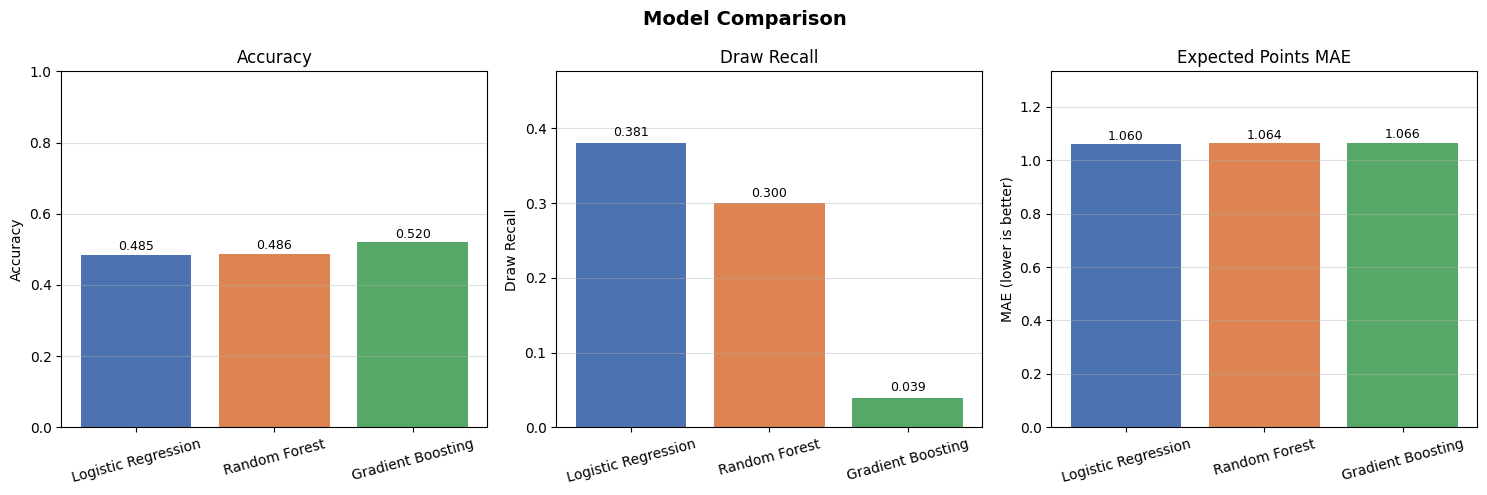

In [25]:
# --- Comparison bar charts ---
colors = ["#4C72B0","#DD8452","#55A868"]
fig, axes = plt.subplots(1, 3, figsize=(15,5))
fig.suptitle("Model Comparison", fontsize=14, fontweight="bold")

for ax, metric, ylabel in zip(
    axes,
    ["Accuracy","Draw Recall","Expected Points MAE"],
    ["Accuracy","Draw Recall","MAE (lower is better)"]
):
    vals  = [r[metric] for r in results]
    names = [r["Model"] for r in results]
    bars  = ax.bar(names, vals, color=colors)
    ax.set_title(metric); ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals)*1.25 if metric!="Accuracy" else 1.0)
    ax.grid(axis="y", alpha=0.4)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


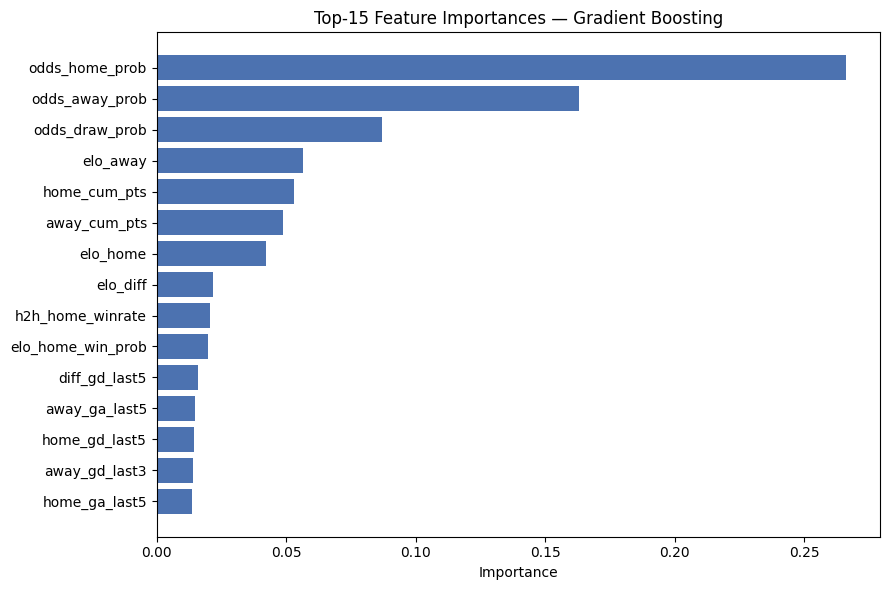

<Figure size 640x480 with 0 Axes>

In [26]:

# --- Feature Importance (Gradient Boosting) ---
clf = trained["Gradient Boosting"].named_steps["clf"]
fi = pd.DataFrame({"feature": FEATURE_COLS, "importance": clf.feature_importances_}) \
       .sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(9,6))
plt.barh(fi["feature"], fi["importance"], color="#4C72B0")
plt.xlabel("Importance"); plt.title("Top-15 Feature Importances — Gradient Boosting")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

plt.tight_layout()
plt.show()

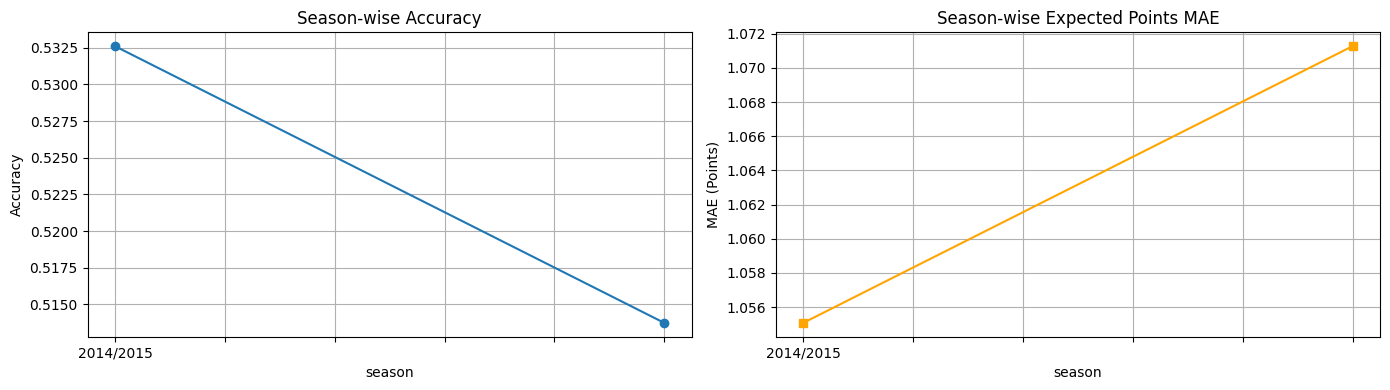

In [27]:

# --- Season-wise accuracy & MAE ---
season_test = model_df.loc[X_test.index, "season"]
season_eval = pd.DataFrame({
    "season":          season_test.values,
    "y_true":          y_test.values,
    "y_pred":          best_result["y_pred"],
    "expected_points": best_result["expected_pts"],
    "actual_points":   best_result["actual_pts"].values,
})

season_acc = season_eval.groupby("season").apply(lambda d: (d["y_true"]==d["y_pred"]).mean())
season_mae = season_eval.groupby("season").apply(
    lambda d: mean_absolute_error(d["actual_points"], d["expected_points"])
)

fig, axes = plt.subplots(1, 2, figsize=(14,4))
season_acc.plot(kind="line", marker="o", ax=axes[0], title="Season-wise Accuracy")
axes[0].set_ylabel("Accuracy"); axes[0].grid(True)
season_mae.plot(kind="line", marker="s", color="orange", ax=axes[1],
                title="Season-wise Expected Points MAE")
axes[1].set_ylabel("MAE (Points)"); axes[1].grid(True)
plt.tight_layout()
plt.show()

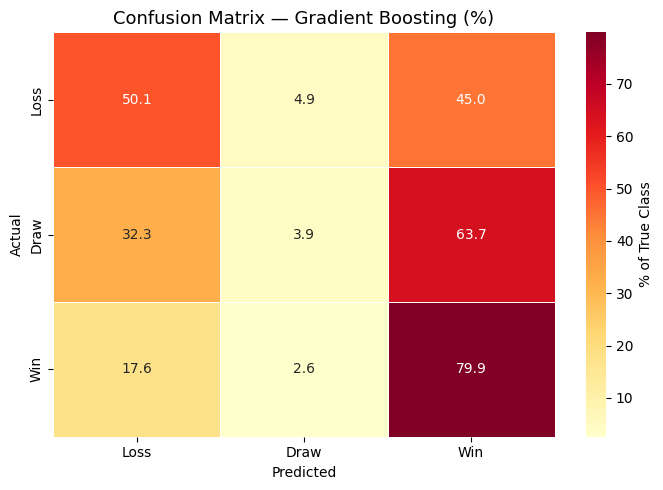

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# ════════════════════════════════════════════════════════════
# CONFUSION MATRIX
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7,5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(
    cm_pct,
    annot=True,
    fmt=".1f",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "% of True Class"},
    ax=ax
)

ax.set_title(f"Confusion Matrix — {best_name} (%)", fontsize=13, color="black")
ax.set_xlabel("Predicted", color="black")
ax.set_ylabel("Actual", color="black")
ax.tick_params(colors="black")

plt.tight_layout()
plt.show()

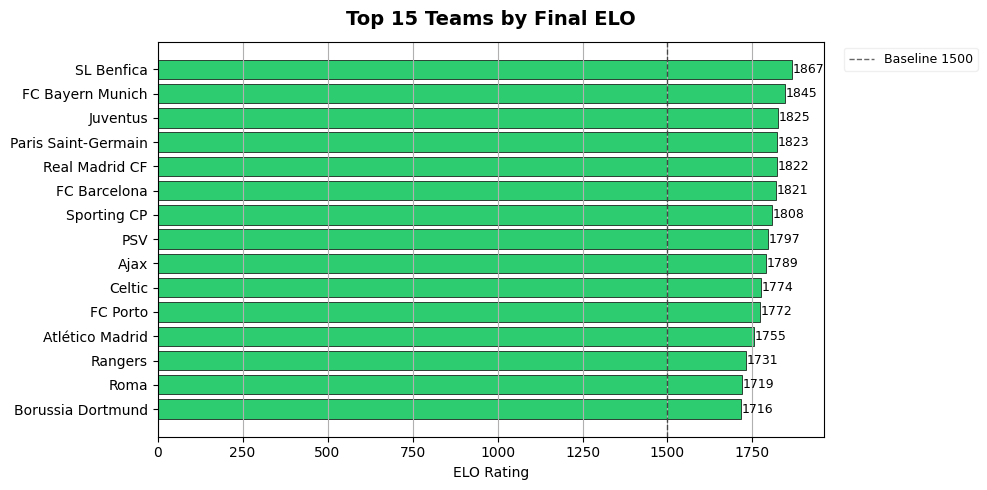

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Define COLORS dictionary (fix)
COLORS = {
    "win": "#2ecc71",
    "draw": "#f39c12",
    "loss": "#e74c3c"
}

# ── Plot: Top 15 Teams by Final ELO ──
fig, ax = plt.subplots(figsize=(10,5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plt.title("Top 15 Teams by Final ELO",
          fontsize=14,
          fontweight="bold",
          color="black",
          pad=12)

final_elo = {}

for _, row in model_df.sort_values("date").iterrows():
    final_elo[row["home_team"]] = row["elo_home"]
    final_elo[row["away_team"]] = row["elo_away"]

elo_series = pd.Series(final_elo).dropna().sort_values(ascending=False).head(15)

bar_colors = [
    COLORS["win"] if v >= 1550 else
    COLORS["draw"] if v >= 1500 else
    COLORS["loss"]
    for v in elo_series.values
]

bars = ax.barh(
    elo_series.index[::-1],
    elo_series.values[::-1],
    color=bar_colors[::-1],
    edgecolor="black",
    linewidth=0.5
)

ax.axvline(1500,
           color="black",
           linestyle="--",
           linewidth=1,
           alpha=0.6,
           label="Baseline 1500")

ax.set_xlabel("ELO Rating", color="black")
ax.tick_params(colors="black")

ax.grid(axis="x")

# Value labels
for bar, val in zip(bars, elo_series.values[::-1]):
    ax.text(
        val + 2,
        bar.get_y() + bar.get_height()/2,
        f"{val:.0f}",
        va="center",
        fontsize=9,
        color="black"
    )

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.show()

## Section 11b: SHAP Explainability

> WHY did the model make each prediction?
> SHAP assigns a contribution score to every feature for every prediction.

Computing SHAP values for Gradient Boosting...


PermutationExplainer explainer: 301it [02:25,  2.05it/s]                         


SHAP values computed ✓  |  shape per class: (300, 33)


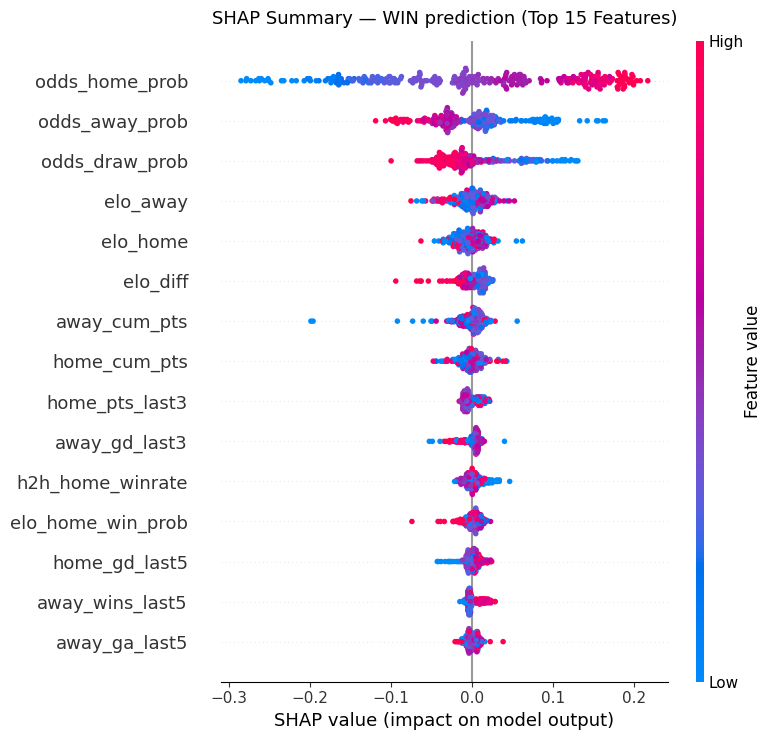

In [33]:
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

import matplotlib.pyplot as plt

print("Computing SHAP values for Gradient Boosting...")

gb_clf    = trained["Gradient Boosting"].named_steps["clf"]
scaler    = trained["Gradient Boosting"].named_steps["scaler"]

X_test_sc = scaler.transform(X_test)
X_test_sc = pd.DataFrame(X_test_sc, columns=FEATURE_COLS)

# ── Use PermutationExplainer (works well with multiclass) ──
background  = shap.sample(X_test_sc, 100, random_state=42)
explainer   = shap.PermutationExplainer(gb_clf.predict_proba, background)

X_shap = X_test_sc.iloc[:300].reset_index(drop=True)

shap_obj = explainer(X_shap)

# shap_obj.values shape → (samples, features, classes)
sv_win  = shap_obj.values[:, :, 2]
sv_draw = shap_obj.values[:, :, 1]
sv_loss = shap_obj.values[:, :, 0]

sv = [sv_loss, sv_draw, sv_win]

print(f"SHAP values computed ✓  |  shape per class: {sv_win.shape}")

# ── Reset style to normal (fix dark background) ──
plt.style.use("default")

# ── SHAP Plot: Summary for WIN class ──
fig = plt.figure(figsize=(10,7), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

shap.summary_plot(
    sv_win,
    X_shap,
    feature_names=FEATURE_COLS,
    plot_type="dot",
    max_display=15,
    show=False
)

plt.title("SHAP Summary — WIN prediction (Top 15 Features)", fontsize=13, pad=12)

plt.tight_layout()
plt.show()

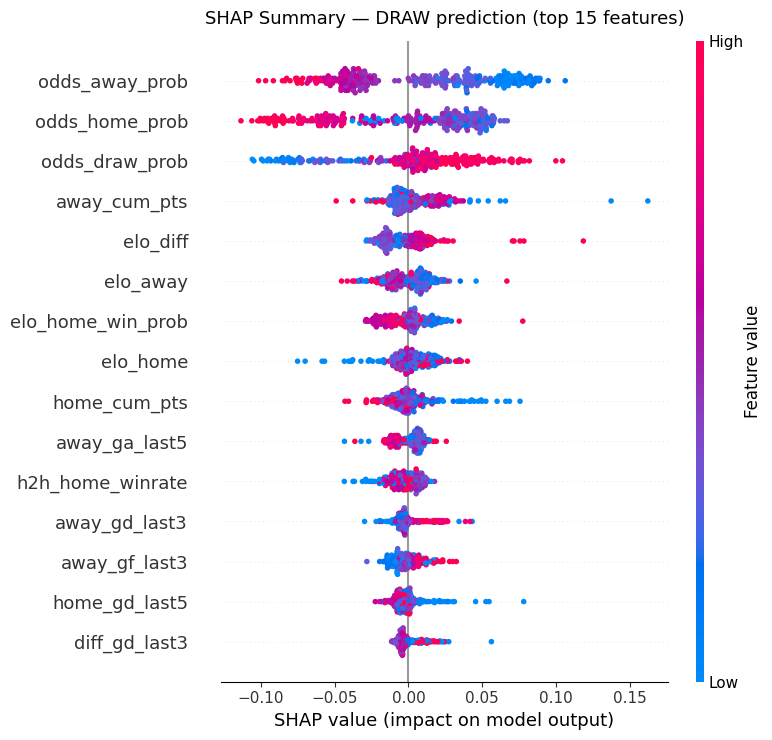

In [34]:
# ── SHAP Plot 2: Summary — Draw class ──
plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv_draw, X_shap,
    feature_names=FEATURE_COLS,
    plot_type="dot", show=False, max_display=15
)
plt.title("SHAP Summary — DRAW prediction (top 15 features)", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

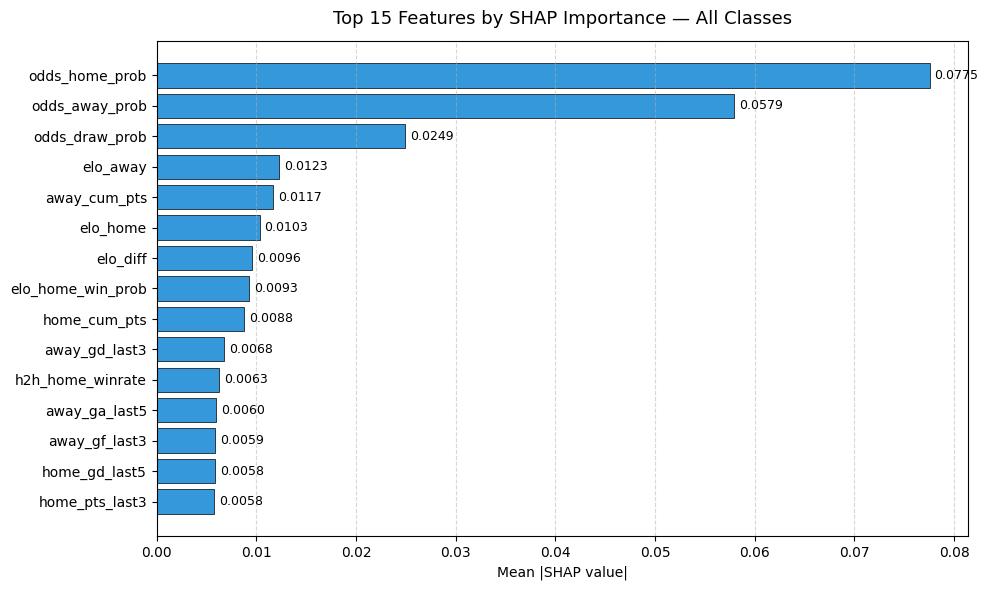

In [35]:
# ── SHAP Plot 3: Mean absolute importance bar ──
mean_abs_shap = np.abs(shap_obj.values).mean(axis=(0, 2))  # avg over samples & classes

shap_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "shap_mean": mean_abs_shap
}).sort_values("shap_mean", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bars = ax.barh(
    shap_importance["feature"][::-1],
    shap_importance["shap_mean"][::-1],
    color="#3498db",
    edgecolor="black",
    linewidth=0.5
)

for bar, val in zip(bars, shap_importance["shap_mean"][::-1]):
    ax.text(
        val + 0.0005,
        bar.get_y() + bar.get_height()/2,
        f"{val:.4f}",
        va="center",
        fontsize=9,
        color="black"
    )

ax.set_xlabel("Mean |SHAP value|", color="black")

ax.set_title(
    "Top 15 Features by SHAP Importance — All Classes",
    fontsize=13,
    color="black",
    pad=12
)

ax.tick_params(colors="black")

ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


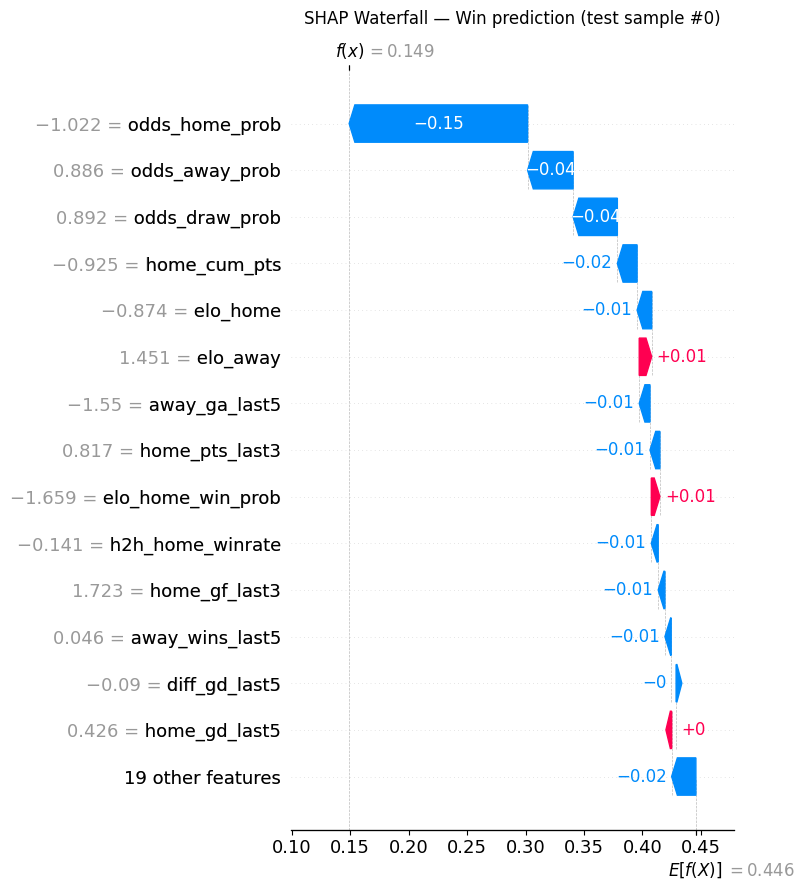


✅ All SHAP plots complete.


In [36]:
# ── SHAP Plot 4: Waterfall for single match — Win class ──
sample_idx = 0
shap_exp = shap.Explanation(
    values        = shap_obj.values[sample_idx, :, 2],
    base_values   = shap_obj.base_values[sample_idx, 2],
    data          = X_shap.values[sample_idx],
    feature_names = FEATURE_COLS
)
plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_exp, max_display=15, show=False)
plt.title(f"SHAP Waterfall — Win prediction (test sample #{sample_idx})",
          fontsize=12, pad=12)
plt.tight_layout()
plt.show()
print("\n✅ All SHAP plots complete.")

## Section 12: Calibration — Expected vs Actual Points

In [37]:
comparison_df = pd.DataFrame({
    "expected_points": best_result["expected_pts"],
    "actual_points":   best_result["actual_pts"].values
}, index=X_test.index)

comparison_df["expected_bucket"] = pd.qcut(
    comparison_df["expected_points"], q=5, duplicates="drop"
)
comparison_df.groupby("expected_bucket")[["expected_points","actual_points"]].mean()

# Confidence vs Correctness
max_conf = best_result["proba"].max(axis=1)
conf_df  = pd.DataFrame({
    "confidence": max_conf,
    "correct": (best_result["y_pred"] == y_test.values)
})
conf_df.groupby(pd.qcut(conf_df["confidence"], 5))["correct"].mean()

confidence
(0.334, 0.413]    0.370180
(0.413, 0.472]    0.425450
(0.472, 0.541]    0.476864
(0.541, 0.661]    0.561697
(0.661, 0.955]    0.763496
Name: correct, dtype: float64

## Section 13: Predict a New Match

In [38]:
def predict_match(home_team: str, away_team: str, model, model_df: pd.DataFrame) -> dict:
    def get_side(team, side):
        rows = model_df[model_df[f"{side}_team"]==team].sort_values("date")
        if rows.empty: raise ValueError(f"Team not found: {team}")
        return rows.iloc[-1]

    h_row = get_side(home_team, "home")
    a_row = get_side(away_team, "away")

    elo_h = h_row["elo_home"]; elo_a = a_row["elo_away"]
    elo_diff = elo_h - elo_a
    elo_wp   = 1.0 / (1.0 + 10.0**(-elo_diff/400.0))

    h2h = model_df[
        ((model_df["home_team"]==home_team)&(model_df["away_team"]==away_team)) |
        ((model_df["home_team"]==away_team)&(model_df["away_team"]==home_team))
    ].sort_values("date")
    h2h_rate = h2h.iloc[-1]["h2h_home_winrate"] if len(h2h)>0 else 0.5

    # Betting odds — use latest available for each team
    odds_h = h_row.get("odds_home_prob", np.nan)
    odds_d = (h_row.get("odds_draw_prob", np.nan) + a_row.get("odds_draw_prob", np.nan)) / 2
    odds_a = a_row.get("odds_away_prob", np.nan)

    feats = {
        "home_gf_last3":h_row["home_gf_last3"],"home_ga_last3":h_row["home_ga_last3"],
        "home_gd_last3":h_row["home_gd_last3"],"home_wins_last3":h_row["home_wins_last3"],
        "home_pts_last3":h_row["home_pts_last3"],
        "away_gf_last3":a_row["away_gf_last3"],"away_ga_last3":a_row["away_ga_last3"],
        "away_gd_last3":a_row["away_gd_last3"],"away_wins_last3":a_row["away_wins_last3"],
        "away_pts_last3":a_row["away_pts_last3"],
        "home_gf_last5":h_row["home_gf_last5"],"home_ga_last5":h_row["home_ga_last5"],
        "home_gd_last5":h_row["home_gd_last5"],"home_wins_last5":h_row["home_wins_last5"],
        "away_gf_last5":a_row["away_gf_last5"],"away_ga_last5":a_row["away_ga_last5"],
        "away_gd_last5":a_row["away_gd_last5"],"away_wins_last5":a_row["away_wins_last5"],
        "diff_gd_last3":h_row["home_gd_last3"]-a_row["away_gd_last3"],
        "diff_wins_last3":h_row["home_wins_last3"]-a_row["away_wins_last3"],
        "diff_pts_last3":h_row["home_pts_last3"]-a_row["away_pts_last3"],
        "diff_gd_last5":h_row["home_gd_last5"]-a_row["away_gd_last5"],
        "diff_wins_last5":h_row["home_wins_last5"]-a_row["away_wins_last5"],
        "home_cum_pts":h_row["home_cum_pts"],"away_cum_pts":a_row["away_cum_pts"],
        "elo_home":elo_h,"elo_away":elo_a,"elo_diff":elo_diff,"elo_home_win_prob":elo_wp,
        "h2h_home_winrate":h2h_rate,
        "odds_home_prob": odds_h,
        "odds_draw_prob": odds_d,
        "odds_away_prob": odds_a,
    }
    X_new  = pd.DataFrame([feats])[FEATURE_COLS]
    probs  = model.predict_proba(X_new)[0]
    pred   = model.predict(X_new)[0]

    home_win = probs[2]
    draw     = probs[1]
    away_win = probs[0]

    return {
        "home_team"   : home_team,
        "away_team"   : away_team,
        "prediction"  : LABEL_NAMES[pred],
        "home_win"    : home_win,
        "draw"        : draw,
        "away_win"    : away_win,
        "home_exp_pts": round(float(1*draw + 3*home_win), 3),
        "away_exp_pts": round(float(1*draw + 3*away_win), 3),
    }


# ── Interactive User Input ─────────────────────────────────────────────────

available_teams = sorted(
    set(model_df["home_team"].dropna()) | set(model_df["away_team"].dropna())
)

def find_team(name, teams):
    """
    Level 1 — exact case-insensitive match:  'arsenal' → 'Arsenal'
    Level 2 — substring match (auto-select if only 1 result):
               'manchester u' → 'Manchester United'
    """
    name_clean = name.strip().lower()

    # Level 1: exact
    for t in teams:
        if t.lower() == name_clean:
            return t

    # Level 2: substring — auto-pick only if exactly 1 result
    matches = [t for t in teams if name_clean in t.lower()]
    if len(matches) == 1:
        return matches[0]

    return None

def fuzzy_suggest(name, teams):
    """Same pattern as your snippet — input substring inside team name."""
    return [t for t in teams if name.strip().lower() in t.lower()]

def validate_team(prompt, teams):
    while True:
        raw   = input(prompt).strip()
        match = find_team(raw, teams)
        if match:
            if match.lower() != raw.lower():
                print(f"  ✅ '{raw}'  →  matched as: '{match}'")
            else:
                print(f"  ✅ Matched: {match}")
            return match

        suggestions = fuzzy_suggest(raw, teams)
        if suggestions:
            print(f"  ❌ '{raw}' not found. Did you mean:")
            for s in suggestions:
                print(f"       • {s}")
        else:
            print(f"  ❌ '{raw}' not found.")
            print(f"     Run  print(available_teams)  to see all teams.")

print("⚽ Football Match Predictor")
print("=" * 45)
print("Examples — Arsenal, Liverpool, Chelsea, Manchester City")
print("=" * 45)

home_input = validate_team("Enter Home Team: ", available_teams)
away_input = validate_team("Enter Away Team: ", available_teams)

r = predict_match(home_input, away_input, best_model, model_df)

if r["prediction"] == "Win":
    winner_line = f"🏆 Predicted Winner: {r['home_team']}"
elif r["prediction"] == "Loss":
    winner_line = f"🏆 Predicted Winner: {r['away_team']}"
else:
    winner_line = "🤝 Predicted Result : Draw"

print(f"""
╔{'═'*45}╗
  ⚽  {r['home_team']}  vs  {r['away_team']}
╠{'═'*45}╣
  {winner_line}
╠{'═'*45}╣
  {'Team':<22} {'Home':>10} {'Away':>10}
  {'-'*43}
  {'Win %':<22} {r['home_win']*100:>9.1f}% {r['away_win']*100:>9.1f}%
  {'Draw %':<22} {r['draw']*100:>9.1f}% {r['draw']*100:>9.1f}%
  {'Loss %':<22} {r['away_win']*100:>9.1f}% {r['home_win']*100:>9.1f}%
  {'Expected Points':<22} {r['home_exp_pts']:>10} {r['away_exp_pts']:>10}
╚{'═'*45}╝
""")

display(pd.DataFrame([{
    "Team"            : r["home_team"],
    "Role"            : "Home",
    "Win %"           : f"{r['home_win']*100:.1f}%",
    "Draw %"          : f"{r['draw']*100:.1f}%",
    "Loss %"          : f"{r['away_win']*100:.1f}%",
    "Expected Points" : r["home_exp_pts"],
}, {
    "Team"            : r["away_team"],
    "Role"            : "Away",
    "Win %"           : f"{r['away_win']*100:.1f}%",
    "Draw %"          : f"{r['draw']*100:.1f}%",
    "Loss %"          : f"{r['home_win']*100:.1f}%",
    "Expected Points" : r["away_exp_pts"],
}]))

⚽ Football Match Predictor
Examples — Arsenal, Liverpool, Chelsea, Manchester City
  ✅ Matched: Arsenal
  ✅ Matched: Liverpool

╔═════════════════════════════════════════════╗
  ⚽  Arsenal  vs  Liverpool
╠═════════════════════════════════════════════╣
  🏆 Predicted Winner: Arsenal
╠═════════════════════════════════════════════╣
  Team                         Home       Away
  -------------------------------------------
  Win %                       57.9%      29.5%
  Draw %                      12.6%      12.6%
  Loss %                      29.5%      57.9%
  Expected Points             1.862      1.012
╚═════════════════════════════════════════════╝



,Team,Role,Win %,Draw %,Loss %,Expected Points
0,Arsenal,Home,57.9%,12.6%,29.5%,1.862
1,Liverpool,Away,29.5%,12.6%,57.9%,1.012


## Section 14: Advanced Visualizations

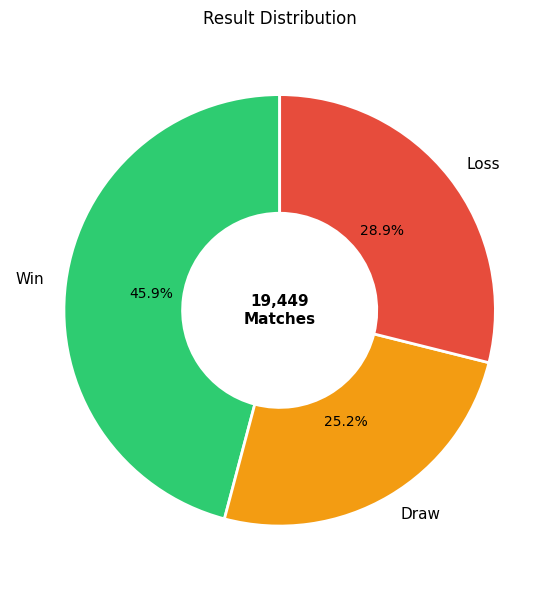

In [50]:
# PANEL 1 — Result Donut

COLORS = {
    "win": "#2ecc71",
    "draw": "#f39c12",
    "loss": "#e74c3c"
}

fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

counts = model_df["result"].value_counts()[["Win","Draw","Loss"]]

wedge_colors = [COLORS["win"], COLORS["draw"], COLORS["loss"]]

wedges, texts, autotexts = ax.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    colors=wedge_colors,
    startangle=90,
    wedgeprops={
        "width":0.55,
        "edgecolor":"white",
        "linewidth":2
    },
    textprops={
        "color":"black",
        "fontsize":11
    }
)

# percentage text styling
for at in autotexts:
    at.set_fontsize(10)
    at.set_color("black")

ax.set_title("Result Distribution", fontsize=12, pad=12)

# center text
ax.text(
    0,0,
    f"{len(model_df):,}\nMatches",
    ha="center",
    va="center",
    fontsize=11,
    color="black",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

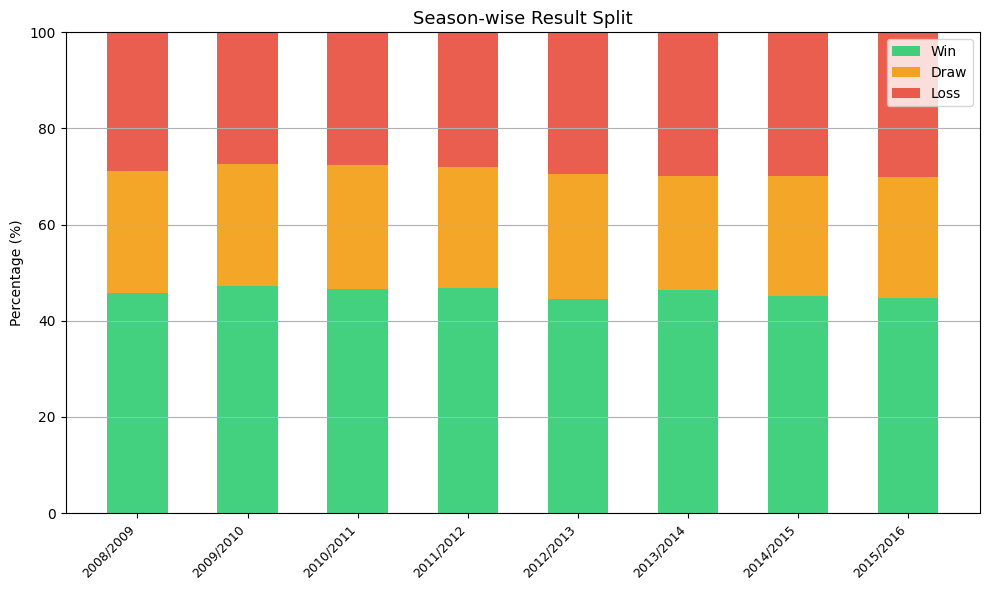

In [66]:
# ── Plot: Season-wise Win/Draw/Loss Stacked Bar ──

COLORS = {
    "win": "#2ecc71",
    "draw": "#f39c12",
    "loss": "#e74c3c"
}

fig, ax = plt.subplots(figsize=(10,6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

season_counts = (
    model_df.groupby(["season","result"])
    .size()
    .unstack(fill_value=0)[["Win","Draw","Loss"]]
)

season_pct = season_counts.div(season_counts.sum(axis=1), axis=0) * 100

seasons = season_pct.index.tolist()
x = np.arange(len(seasons))
w = 0.55

ax.bar(x, season_pct["Win"], w,
       label="Win", color=COLORS["win"], alpha=0.9)

ax.bar(x, season_pct["Draw"], w,
       bottom=season_pct["Win"],
       label="Draw", color=COLORS["draw"], alpha=0.9)

ax.bar(x, season_pct["Loss"], w,
       bottom=season_pct["Win"] + season_pct["Draw"],
       label="Loss", color=COLORS["loss"], alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(seasons, rotation=45, ha="right", fontsize=9)

ax.set_ylabel("Percentage (%)")
ax.set_title("Season-wise Result Split", fontsize=13)

ax.legend(loc="upper right")
ax.grid(axis="y")

ax.set_ylim(0,100)

plt.tight_layout()
plt.show()

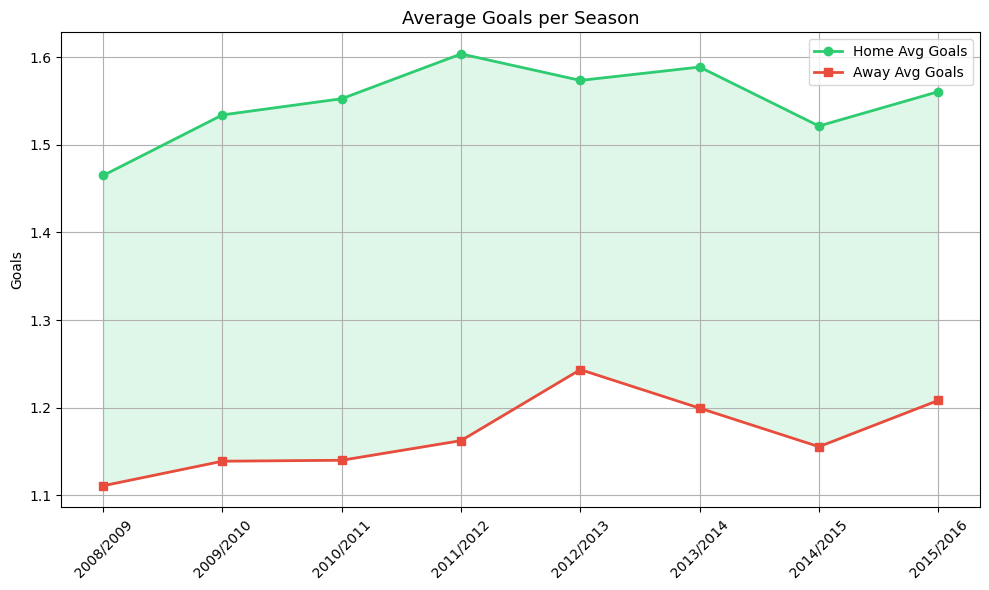

In [ ]:
# ── Plot: Home vs Away Goals per Season ──

COLORS = {
    "bg": "white",
    "text": "black",
    "home": "#2ecc71",
    "away": "#e74c3c"
}

fig, ax = plt.subplots(figsize=(10,6))
fig.patch.set_facecolor(COLORS["bg"])
ax.set_facecolor(COLORS["bg"])

season_goals = model_df.groupby("season").agg(
    home_avg=("home_team_goal","mean"),
    away_avg=("away_team_goal","mean")
)

ax.plot(
    season_goals.index,
    season_goals["home_avg"],
    marker="o",
    color=COLORS["home"],
    linewidth=2,
    label="Home Avg Goals"
)

ax.plot(
    season_goals.index,
    season_goals["away_avg"],
    marker="s",
    color=COLORS["away"],
    linewidth=2,
    label="Away Avg Goals"
)

ax.fill_between(
    season_goals.index,
    season_goals["home_avg"],
    season_goals["away_avg"],
    alpha=0.15,
    color=COLORS["home"]
)

ax.set_title("Average Goals per Season", fontsize=13, color=COLORS["text"])
ax.set_ylabel("Goals")
ax.tick_params(axis="x", rotation=45)

ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


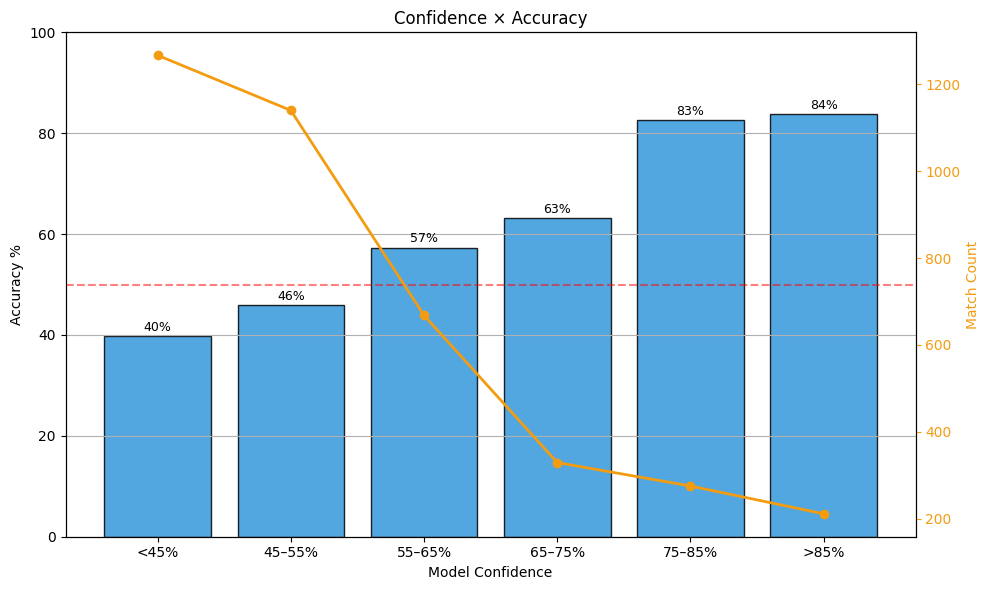

In [83]:
# PANEL 3 — Confidence vs Accuracy

COLORS = {
    "bg": "white",
    "text": "black",
    "win": "#2ecc71",
    "draw": "#f39c12",
    "loss": "#e74c3c",
    "home": "#3498db"
}

fig, ax = plt.subplots(figsize=(10,6))
fig.patch.set_facecolor(COLORS["bg"])
ax.set_facecolor(COLORS["bg"])

# Model confidence
proba_best = best_model.predict_proba(X_test)
max_conf = proba_best.max(axis=1)

correct = (y_pred_best == y_test.values)

conf_df = pd.DataFrame({
    "confidence": max_conf,
    "correct": correct
})

conf_df["bucket"] = pd.cut(
    conf_df["confidence"],
    bins=[0,.45,.55,.65,.75,.85,1.0],
    labels=["<45%","45–55%","55–65%","65–75%","75–85%",">85%"]
)

bucket_acc = conf_df.groupby("bucket")["correct"].mean() * 100
bucket_cnt = conf_df.groupby("bucket")["correct"].count()

# Bar plot (accuracy)
bar_c = ax.bar(
    bucket_acc.index,
    bucket_acc.values,
    color=COLORS["home"],
    alpha=0.85,
    edgecolor="black"
)

# Secondary axis
ax2 = ax.twinx()

ax2.plot(
    bucket_cnt.index,
    bucket_cnt.values,
    color=COLORS["draw"],
    marker="o",
    linewidth=2,
    label="# Matches"
)

ax2.set_ylabel("Match Count", color=COLORS["draw"])
ax2.tick_params(colors=COLORS["draw"])

ax.set_xlabel("Model Confidence")
ax.set_ylabel("Accuracy %")
ax.set_title("Confidence × Accuracy", fontsize=12)

ax.set_ylim(0,100)
ax.grid(axis="y")

ax.axhline(50, color="red", linestyle="--", alpha=0.5)

for bar, val in zip(bar_c, bucket_acc.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 1,
        f"{val:.0f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

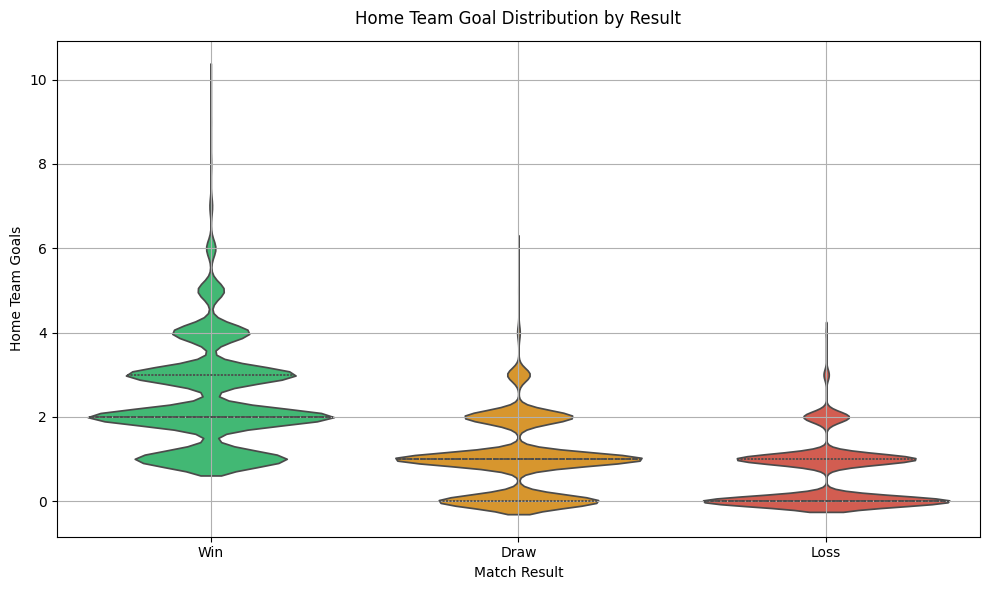

In [86]:
# ── Plot 7: Goal Distribution by Result ──

COLORS = {
    "bg": "white",
    "text": "black",
    "win": "#2ecc71",
    "draw": "#f39c12",
    "loss": "#e74c3c"
}

fig, ax = plt.subplots(figsize=(10,6))
fig.patch.set_facecolor(COLORS["bg"])
ax.set_facecolor(COLORS["bg"])

sns.violinplot(
    x="result",
    y="home_team_goal",
    data=model_df,
    order=["Win","Draw","Loss"],
    palette=[COLORS["win"], COLORS["draw"], COLORS["loss"]],
    ax=ax,
    inner="quartile"
)

ax.set_title("Home Team Goal Distribution by Result", fontsize=12, pad=12)
ax.set_xlabel("Match Result")
ax.set_ylabel("Home Team Goals")

ax.grid(True)

plt.tight_layout()
plt.show()


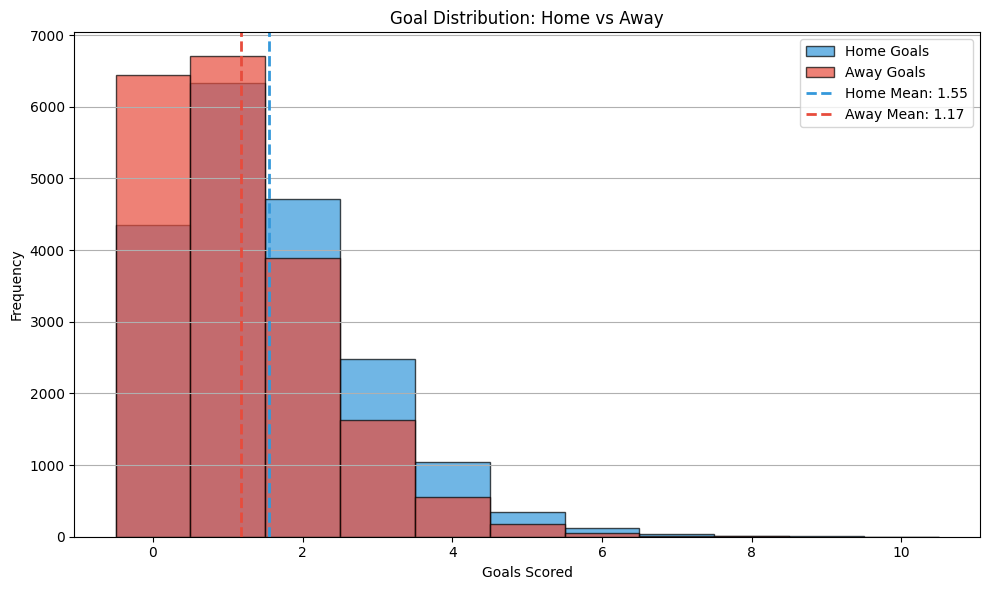

In [89]:
# ── Plot 7: Goal Distribution Home vs Away ──

COLORS = {
    "bg": "white",
    "text": "black",
    "win": "#2ecc71",
    "draw": "#f39c12",
    "loss": "#e74c3c",
    "home": "#3498db",
    "away": "#e74c3c"
}

fig, ax = plt.subplots(figsize=(10,6))
fig.patch.set_facecolor(COLORS["bg"])
ax.set_facecolor(COLORS["bg"])

max_g = int(max(model_df["home_team_goal"].max(),
                model_df["away_team_goal"].max()))

bins = np.arange(-0.5, max_g + 1.5, 1)

ax.hist(
    model_df["home_team_goal"],
    bins=bins,
    alpha=0.7,
    color=COLORS["home"],
    label="Home Goals",
    edgecolor="black"
)

ax.hist(
    model_df["away_team_goal"],
    bins=bins,
    alpha=0.7,
    color=COLORS["away"],
    label="Away Goals",
    edgecolor="black"
)

home_mean = model_df["home_team_goal"].mean()
away_mean = model_df["away_team_goal"].mean()

ax.axvline(home_mean,
           color=COLORS["home"],
           linestyle="--",
           linewidth=2,
           label=f"Home Mean: {home_mean:.2f}")

ax.axvline(away_mean,
           color=COLORS["away"],
           linestyle="--",
           linewidth=2,
           label=f"Away Mean: {away_mean:.2f}")

ax.set_xlabel("Goals Scored")
ax.set_ylabel("Frequency")
ax.set_title("Goal Distribution: Home vs Away")

ax.legend()
ax.grid(axis="y")

plt.tight_layout()
plt.show()

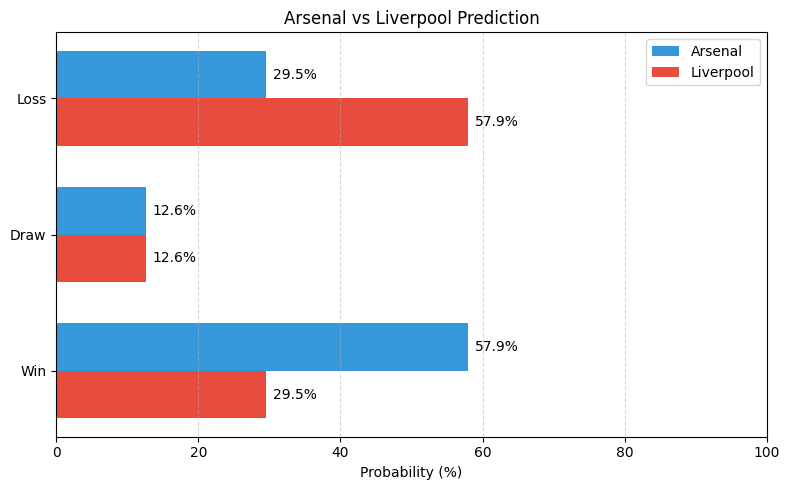

In [92]:
# ─────────────────────────────────────────
# Match Prediction Probability Plot
# ─────────────────────────────────────────

COLORS = {
    "bg": "white",
    "text": "black",
    "home": "#3498db",
    "away": "#e74c3c"
}

fig, ax = plt.subplots(figsize=(8,5))

fig.patch.set_facecolor(COLORS["bg"])
ax.set_facecolor(COLORS["bg"])

categories = ["Win", "Draw", "Loss"]

home_vals = [r["home_win"]*100, r["draw"]*100, r["away_win"]*100]
away_vals = [r["away_win"]*100, r["draw"]*100, r["home_win"]*100]

y = np.arange(len(categories))
h = 0.35

bars1 = ax.barh(y + h/2, home_vals, h,
                color=COLORS["home"],
                label=r["home_team"])

bars2 = ax.barh(y - h/2, away_vals, h,
                color=COLORS["away"],
                label=r["away_team"])

ax.set_yticks(y)
ax.set_yticklabels(categories)

# IMPORTANT FIX
ax.set_xlim(0,100)

ax.set_xlabel("Probability (%)")
ax.set_title(f"{r['home_team']} vs {r['away_team']} Prediction")

ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.legend()

for bar in bars1:
    ax.text(bar.get_width()+1,
            bar.get_y()+bar.get_height()/2,
            f"{bar.get_width():.1f}%",
            va="center")

for bar in bars2:
    ax.text(bar.get_width()+1,
            bar.get_y()+bar.get_height()/2,
            f"{bar.get_width():.1f}%",
            va="center")

plt.tight_layout()
plt.show()

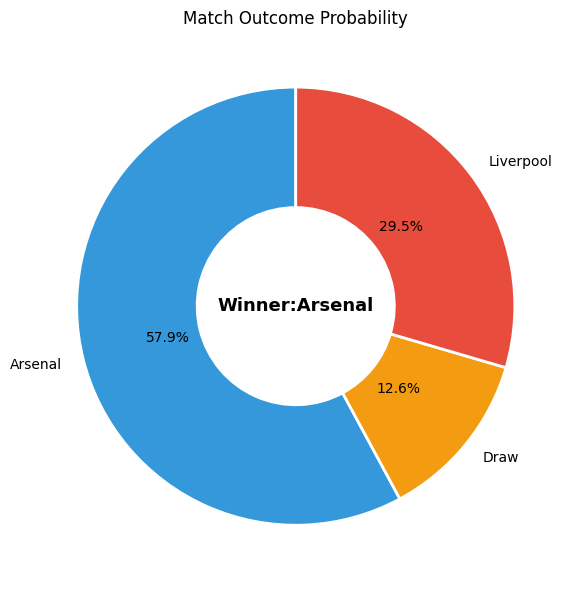

In [105]:
# ── Centre: Donut probability ──

COLORS = {
    "bg": "white",
    "text": "black",
    "home": "#3498db",
    "draw": "#f39c12",
    "away": "#e74c3c"
}

fig, ax = plt.subplots(figsize=(6,6))
fig.patch.set_facecolor(COLORS["bg"])
ax.set_facecolor(COLORS["bg"])

donut_vals = [r["home_win"], r["draw"], r["away_win"]]

donut_labels = [
    r["home_team"],
    "Draw",
    r["away_team"]
]

donut_colors = [
    COLORS["home"],
    COLORS["draw"],
    COLORS["away"]
]

wedges, _, autotexts = ax.pie(
    donut_vals,
    labels=donut_labels,
    autopct="%1.1f%%",
    colors=donut_colors,
    startangle=90,
    wedgeprops={
        "width":0.55,
        "edgecolor":COLORS["bg"],
        "linewidth":2
    },
    textprops={"color":COLORS["text"]}
)

# Winner text in centre
if r["prediction"] == "Win":
    centre_txt = f"Winner:{r['home_team']}"
elif r["prediction"] == "Loss":
    centre_txt = f"Winner:{r['away_team']}"
else:
    centre_txt = "Draw"

ax.text(
    0,0,
    centre_txt,
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

ax.set_title("Match Outcome Probability")

plt.tight_layout()
plt.show()

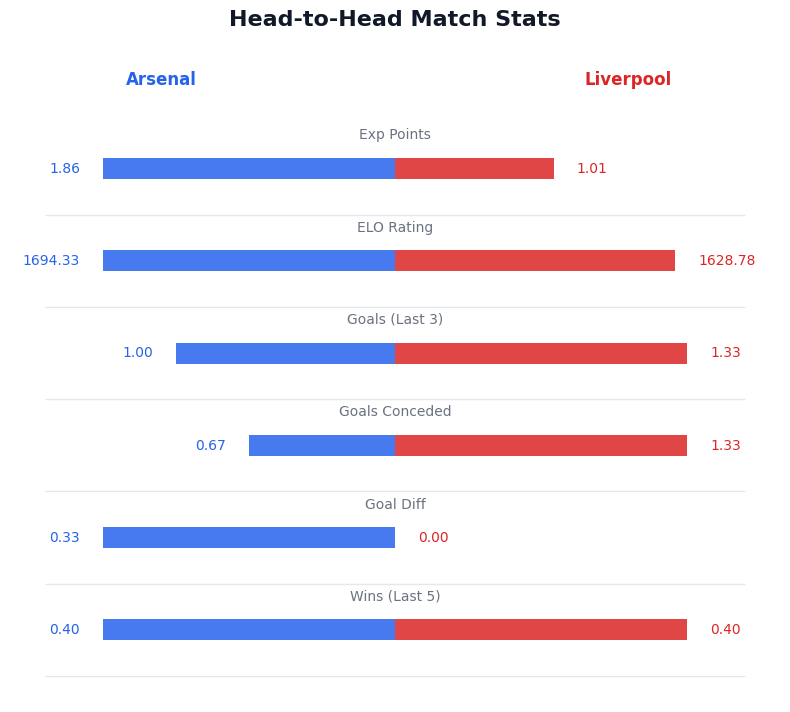

In [104]:
# ── Clean White Head-to-Head Stats Card ──

COLORS = {
    "bg": "white",
    "panel": "#f8fafc",
    "text": "#111827",
    "subtext": "#6b7280",
    "line": "#e5e7eb",
    "home": "#2563eb",
    "away": "#dc2626"
}

fig, ax = plt.subplots(figsize=(8,6))

fig.patch.set_facecolor(COLORS["bg"])
ax.set_facecolor(COLORS["panel"])
ax.axis("off")

home_last = model_df[
    model_df["home_team"] == r["home_team"]
].sort_values("date").iloc[-1]

away_last = model_df[
    model_df["away_team"] == r["away_team"]
].sort_values("date").iloc[-1]

stats = [
("Exp Points", r["home_exp_pts"], r["away_exp_pts"]),
("ELO Rating", home_last["elo_home"], away_last["elo_away"]),
("Goals (Last 3)", home_last["home_gf_last3"], away_last["away_gf_last3"]),
("Goals Conceded", home_last["home_ga_last3"], away_last["away_ga_last3"]),
("Goal Diff", home_last["home_gd_last3"], away_last["away_gd_last3"]),
("Wins (Last 5)", home_last["home_wins_last5"], away_last["away_wins_last5"])
]

# Title
ax.text(
0.5, 0.95,
"Head-to-Head Match Stats",
ha="center",
fontsize=16,
fontweight="bold",
color=COLORS["text"]
)

# Team names
ax.text(
0.3, 0.88,
r["home_team"],
ha="center",
fontsize=12,
fontweight="bold",
color=COLORS["home"]
)

ax.text(
0.7, 0.88,
r["away_team"],
ha="center",
fontsize=12,
fontweight="bold",
color=COLORS["away"]
)

y = 0.78

for label, hval, aval in stats:

    max_val = max(hval, aval) if max(hval, aval) != 0 else 1

    h_width = 0.25 * (hval / max_val)
    a_width = 0.25 * (aval / max_val)

    # bars
    ax.barh(y, h_width, left=0.5-h_width, height=0.025, color=COLORS["home"], alpha=0.85)
    ax.barh(y, a_width, left=0.5, height=0.025, color=COLORS["away"], alpha=0.85)

    # stat label
    ax.text(
        0.5, y+0.035,
        label,
        ha="center",
        fontsize=10,
        color=COLORS["subtext"]
    )

    # values
    ax.text(
        0.5-h_width-0.02,
        y,
        f"{hval:.2f}",
        ha="right",
        va="center",
        fontsize=10,
        color=COLORS["home"]
    )

    ax.text(
        0.5+a_width+0.02,
        y,
        f"{aval:.2f}",
        ha="left",
        va="center",
        fontsize=10,
        color=COLORS["away"]
    )

    # separator line
    ax.hlines(
        y-0.055,
        0.2,
        0.8,
        colors=COLORS["line"],
        linewidth=1
    )

    y -= 0.11

plt.tight_layout()
plt.show()